In [34]:
import os

from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [35]:
load_dotenv()

True

In [36]:
class SubState(TypedDict):
    input_txt : str
    translated_txt : str

In [37]:
subgraph_llm = ChatGroq(
    model="llama-3.3-70b-versatile",  
    temperature=0,
    api_key=os.getenv("GROQ_API_KEY")    
)

In [38]:
def translate_text(state : SubState):
    prompt = f'''
Translate the text into French language.
Make it clear. And do not add extra content.
Text: {state["input_txt"]}'''.strip()
    
    translated_text = subgraph_llm.invoke(prompt).content
    return {'translated_txt' : translated_text}

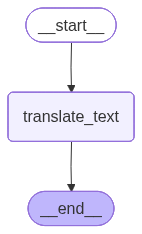

In [39]:
sub_graph = StateGraph(SubState)

sub_graph.add_node('translate_text', translate_text)
sub_graph.add_edge(START, 'translate_text')
sub_graph.add_edge('translate_text', END)

sub_workflow = sub_graph.compile()
sub_workflow

In [40]:
class ParentState(TypedDict):
    question : str
    eng_txt : str
    frn_txt : str

In [41]:
parentgraph_llm = ChatGroq(
    model="llama-3.3-70b-versatile",  
    temperature=0,
    api_key=os.getenv("GROQ_API_KEY")    
)

In [42]:
def generate_eng_answer(state : ParentState):
    prompt = f'''You're a helpfull assistant. Answer clearly to user query or questions.
    Question: {state["question"]}'''.strip()

    eng_txt = parentgraph_llm.invoke(prompt).content
    return {'eng_txt' : eng_txt}

In [43]:
def generate_frn_answer(state : ParentState):
    result = sub_workflow.invoke({'input_txt' : state['eng_txt']})
    return {'frn_txt': result['translated_txt']}

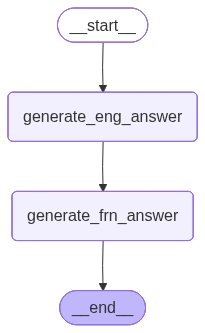

In [44]:
sub_graph_french = StateGraph(ParentState)

sub_graph_french.add_node('generate_eng_answer', generate_eng_answer)
sub_graph_french.add_node('generate_frn_answer', generate_frn_answer)

sub_graph_french.add_edge(START, 'generate_eng_answer')
sub_graph_french.add_edge('generate_eng_answer', 'generate_frn_answer')
sub_graph_french.add_edge('generate_frn_answer', END)

workflow = sub_graph_french.compile()
workflow

In [49]:
user_query = {
    'question' : 'Translate the sentence: Myself Arsal and i study baclors of information technology'    
}

result = workflow.invoke(user_query)
print('English', result['eng_txt'])
print('French', result['frn_txt'])

English The translated sentence in a more formal and grammatically correct tone would be:

"My name is Arsal, and I am studying for a Bachelor's degree in Information Technology."

Or, in a more polished version:

"Hello, I'm Arsal, and I'm currently pursuing a Bachelor's degree in Information Technology."
French La phrase traduite dans un ton plus formel et grammaticalement correct serait :

"Je m'appelle Arsal, et j'étudie pour obtenir un diplôme de bachelor en technologie de l'information."

Ou, dans une version plus polie :

"Bonjour, je m'appelle Arsal, et j'étudie actuellement pour obtenir un diplôme de bachelor en technologie de l'information."


# Note: We can use only ParentState also. As ParentState is shared among it's SubState so it's convnient to use it tough. 
# To do this, we replace SubState with ParentState just.